# Análise dos Efeitos

Vamos começar importando as bibliotecas, carregando os dados contidos na pasta `photos/dataset` e realizando uma exploração incial para entender como as imagens e efeitos estão distribuídos.

In [2]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

plt.rcParams["figure.figsize"] = (10, 6)
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
# Definir transformações básicas para o carregamento das imagens
# Redimensionamos para um tamanho fixo (256x256) e convertemos para Tensor
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Caminho para o diretório de dados onde os efeitos estão distribuídos nas pastas
data_dir = './photos/dataset'

# Carregando o dataset utilizando o torchvision.datasets.ImageFolder
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print(f"Número total de imagens no dataset: {len(dataset)}")
print(f"Número de classes (efeitos + original): {len(dataset.classes)}")
print("\nPrimeiras 10 classes encontradas na pasta:")
for cls in dataset.classes[:10]:
    print(f" - {cls}")

Número total de imagens no dataset: 7686
Número de classes (efeitos + original): 42

Primeiras 10 classes encontradas na pasta:
 - 175807_futuro
 - 175807_maria_e_sobel
 - 175807_pixelular
 - 186629_canny_edge_detection
 - 186629_chromatic_aberration_blur
 - 186629_color_splash
 - 237310_aberracao_cromatica
 - 237310_pixelizacao
 - 237310_quantizacao
 - 241163_chromatic_aberration


In [4]:
from collections import Counter

# Contando a quantidade de imagens para cada efeito
class_counts = Counter(dataset.targets)
class_names = dataset.classes

print("Quantidade de imagens agrupadas por classe:")
for class_idx, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"- {class_names[class_idx]}: {count} imagens")

Quantidade de imagens agrupadas por classe:
- 175807_futuro: 183 imagens
- 175807_maria_e_sobel: 183 imagens
- 175807_pixelular: 183 imagens
- 186629_canny_edge_detection: 183 imagens
- 186629_chromatic_aberration_blur: 183 imagens
- 186629_color_splash: 183 imagens
- 237310_aberracao_cromatica: 183 imagens
- 237310_pixelizacao: 183 imagens
- 237310_quantizacao: 183 imagens
- 241163_chromatic_aberration: 183 imagens
- 241163_edge_detection: 183 imagens
- 241163_pixelation: 183 imagens
- 243360_chromatic_aberration: 183 imagens
- 243360_edge_detection: 183 imagens
- 243360_radial_blur: 183 imagens
- 245609_borda_lapis: 183 imagens
- 245609_fisheye: 183 imagens
- 245609_onda_de_calor: 183 imagens
- 245760_aberracao_cromatica: 183 imagens
- 245760_deteccao_borda: 183 imagens
- 245760_dithering: 183 imagens
- 246955_color_mapping: 183 imagens
- 246955_fish_eye: 183 imagens
- 246955_restricted_chromatic_aberration_and_vignette: 183 imagens
- 247145_border_detection: 183 imagens
- 247145_col

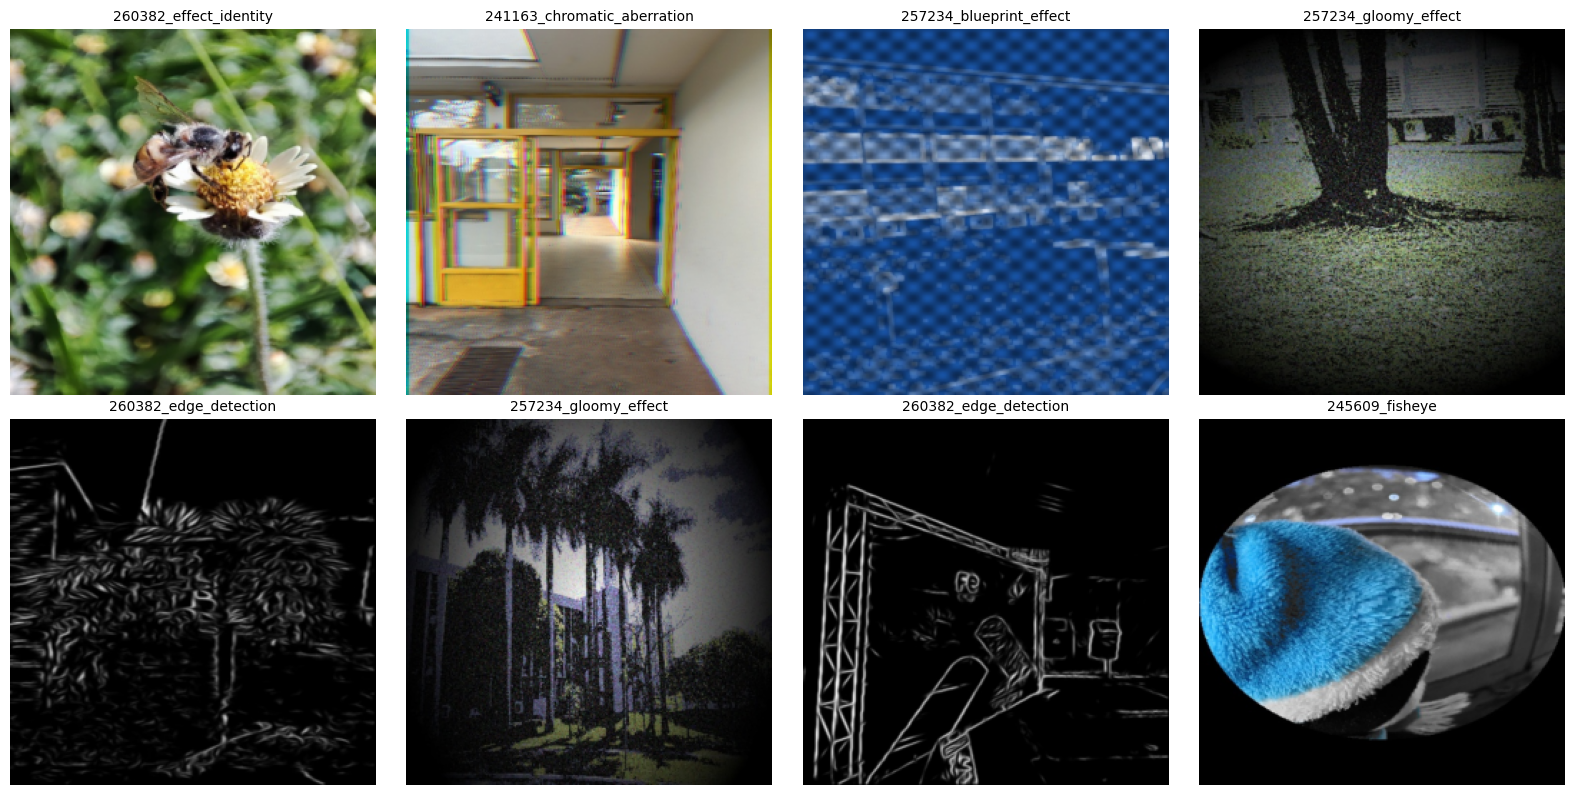

In [5]:
# Função para visualizar algumas das imagens do dataset
def imshow(img, title):
    # Converte o tensor para um array NumPy e muda a dimensão (C, H, W) para (H, W, C)
    img = img.numpy().transpose((1, 2, 0))
    # Para garantir que os valores fiquem entre 0 e 1, pode haver imprecisão nos float
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title, fontsize=10)
    plt.axis('off')

# Criando um DataLoader para embaralhar e pegar um batch de imagens
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
images, labels = next(iter(dataloader))

# Plotando as imagens num grid
fig = plt.figure(figsize=(16, 8))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    # Recupera o nome da classe com base no rótulo da imagem
    imshow(images[i], class_names[labels[i]])
plt.tight_layout()
plt.show()

## 2. Metodologia e Preparação dos Dados

Para garantir que as comparações entre as diferentes abordagens (KNN, Modelo Linear, CNN e ViT) sejam justas, eu precisei utilizar **exatamente a mesma divisão de dados**. 

Dividi o dataset nas proporções solicitadas:
- **80%** para Treinamento
- **15%** para Validação (ajuste de hiperparâmetros)
- **5%** para Teste (avaliação final do melhor modelo)

### ⚠️ Insight Exploratório - Risco de "Data Leakage" (Vazamento de Dados)
Segundo a documentação do projeto: *"O mesmo nome em pastas diferentes corresponde a mesma foto original"*.
Se eu fizesse um split aleatório simples sobre as 7686 fotos, seria **garantido** que a foto base (ex: imagem de um cachorro) caísse no Treino com um Efeito X, e a mesma imagem de cachorro caísse no Teste com o Efeito Y. 

O problema disso é que os modelos (especialmente CNNs ou ViTs) poderiam aprender a decorar as "fotos base" (o fundo, os objetos da foto) em vez de aprender "o que caracteriza o efeito de borda de lápis". 
Como comecei com abordagens padrão para obter uma "Accuracy" de Baseline elevada, fiz uma divisão fixa comum (`random_split` do PyTorch com seed fixa) e fui acompanhando o quanto essa métrica poderia ser enviesada.

In [6]:
from torch.utils.data import random_split

# Precisamos garantir a reproducibilidade usando uma random seed fixa
torch.manual_seed(42)

total_size = len(dataset)
train_size = int(0.80 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size # 5% restantes

# Realizamos o split!
train_dataset, val_dataset, test_dataset = random_split(
    dataset, 
    [train_size, val_size, test_size]
)

print(f"Dataset Total: {total_size} imagens\n")
print(f"Conjunto de Treino (80%): {len(train_dataset)} imagens")
print(f"Conjunto de Validação (15%): {len(val_dataset)} imagens")
print(f"Conjunto de Teste (5%): {len(test_dataset)} imagens")

# Atualizando os DataLoaders para a divisão
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Dataset Total: 7686 imagens

Conjunto de Treino (80%): 6148 imagens
Conjunto de Validação (15%): 1152 imagens
Conjunto de Teste (5%): 386 imagens


## 3. Abordagens de Classificação (Supervisionado)

Os modelos simples para baseline, como KNN e Classificadores Lineares, não lidam muito bem com dimensões grandes (as imagens de 256x256x3 pixels totalizam `196.608 features` na forma bruta). Além de ser muito custoso para treinar. Para contornar isso nas primeiras abordagens, eu decidi aplainar (*flatten*) esses tensores.

A ideia de evolução dos experimentos que planejei foi:
1. **Modelos Básicos (`Scikit-Learn`)**:
   - KNN Clássico.
   - Classificador Linear (SVM ou Regressão Logística).
2. **Modelos de Visão Tradicionais (`PyTorch`)**:
   - CNN (Arquitetura Customizada + Extração de Features + Camada Linear / KNN no Topo).
3. **Abordagem de Estado-da-Arte (SOTA)**:
   - Transfomer de Visão (ViT), com a ideia de tentar chegar na meta de **>90%** de acurácia!


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

# Precisaremos fazer a iteração do Loader de PyTorch e transformá-lo num Array bidimensional para o Scikit-Learn
def flatten_dataloader(loader):
    features = []
    labels = []
    
    for inputs, targets in loader:
        # Achatamento (Flatten) dos dados: De (Batch_Size, Canais, Altura, Largura)
        # Para (Batch_Size, Canais * Altura * Largura), ou seja, achatamos de algo 3D para 1 Vetor Sequencial
        batch_features = inputs.view(inputs.size(0), -1).numpy()
        features.append(batch_features)
        labels.append(targets.numpy())
    
    # Empilhar tudo
    X = np.vstack(features)
    y = np.concatenate(labels)
    return X, y

print("Executando extração das features brutas... (isso precisará lidar com muita memória na RAM)")

start_t = time.time()

# Isso pode levar vários segundos, especialmente com 7686 fotos em alta resolução. 
X_train_raw, y_train_raw = flatten_dataloader(train_loader)
X_val_raw, y_val_raw     = flatten_dataloader(val_loader)
X_test_raw, y_test_raw   = flatten_dataloader(test_loader)

end_t = time.time()
print(f"Dimensões do Treino: {X_train_raw.shape}")
print(f"Tempo levado para o Flatten: {end_t - start_t:.2f} segundos")

Executando extração das features brutas... (isso precisará lidar com muita memória na RAM)
Dimensões do Treino: (6148, 196608)
Tempo levado para o Flatten: 107.27 segundos


### 3.1. Abordagem KNN (K-Nearest Neighbors)

Comecei pelo basilar: um classificador KNN. A minha intuição já dizia que o KNN talvez não performasse muito bem por conta da "Maldição da Dimensionalidade" (a métrica de distância Euclidiana meio que perde o sentido em um espaço com `196.608 features`).

Fiz o teste para medir essa acurácia de base para então ter um ponto de partida para criticar os resultados.

In [8]:
print("Treinando e validando KNN...")

# Definindo K=3 (Olhando os 3 vizinhos mais parecidos da mesma dimensão plana)
knn_model = KNeighborsClassifier(n_neighbors=3, n_jobs=-1) 

start_t = time.time()

# Treinamento do KNN
knn_model.fit(X_train_raw, y_train_raw)

# Fazendo predições no conjunto de Validação para observar a métrica
y_val_pred_knn = knn_model.predict(X_val_raw)
end_t = time.time()

accuracy_knn = accuracy_score(y_val_raw, y_val_pred_knn)

# Reportando o Modelo:
print(f"Tempo de Treino + Predição: {end_t - start_t:.2f} segundos")
print(f"Acurácia KNN na Validação: {accuracy_knn:.2%}")

# Dando uma rápida olhada nas top fclasses para analisar o balanceamento preditivo:
print("\nRelatório de Classificação Detalhado do KNN (Resumo):")
print(classification_report(y_val_raw, y_val_pred_knn, target_names=class_names, zero_division=0))

Treinando e validando KNN...
Tempo de Treino + Predição: 29.19 segundos
Acurácia KNN na Validação: 14.93%

Relatório de Classificação Detalhado do KNN (Resumo):
                                                     precision    recall  f1-score   support

                                      175807_futuro       0.50      0.14      0.22        21
                               175807_maria_e_sobel       0.10      0.04      0.06        25
                                   175807_pixelular       0.03      0.21      0.05        28
                        186629_canny_edge_detection       0.00      0.00      0.00        19
                   186629_chromatic_aberration_blur       0.00      0.00      0.00        30
                                186629_color_splash       0.00      0.00      0.00        27
                         237310_aberracao_cromatica       0.00      0.00      0.00        26
                                 237310_pixelizacao       0.00      0.00      0.00        36
 

### Explorando os dados com Redução de Dimensionalidade (PCA + UMAP)

O resultado de **~14.9% no KNN** comprova nossa hipótese: em um espaço vazio e gigantesco de quase 200 mil dimensões (o modelo lidou com cada pixel RGB individualmente), comparar distâncias euclidianas no KNN perde totalmente o sentido (esse fenômeno é conhecido como *Maldição da Dimensionalidade*).

Como a abordagem supervisionada com dados brutos fracassou, vamos pular momentaneamente para uma técnica de exploração não supervisionada para enxergar o dataset.
Rodar o UMAP puramente em `196.608` colunas vai demorar horas (ou até estourar a memória). O pipeline de boas práticas manda usarmos um `PCA` primeiro (para reduzir de  196k dimensões para poucas dimensões que guardam a maior variância da imagem) e só depois passar o UMAP para comprimir essas em 2 dimensões.

Eu iniciei com 100 dimensões. elas representavam 81.94% da variância dos dados. mas apenas as 10 mais significativas representavam 65.00% de toda a informação.

Ou seja, a informaçao está muito concentrada, mas ainda não é informação suficiente.

Frente a isso, resolvi aumentar para 500 classes, que ainda não deve ser muito para treinar uma rede neural.

Se bem que se usarmos a CNN ou um ViT, usaremos a imagem inteira, mas vamos usar essa análise PCA para treinarmos um simples MLP para termos como comparativo também.

Visualização do PCA 100 dimensões + UMAP 2 dimensões
![imageCartesiano.png](imageCartesiano.png)

Tentei colocar em coordenadas polares para ver se conseguiamos ver padrões e clusters, mas também não tivemos sucesso.
![imagePolar.png](imagePolar.png)

Iniciando redução inicial (PCA) das imagens: de ~196k para 500 dimensões temporárias (para não travar a memória)...
Iniciando compressão UMAP: das 500 dimensões da PCA para 2 (Plotagem)...


/home/joao/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processo concluído! Criando o Mapeamento e Scatter Plot 2D de Análise...


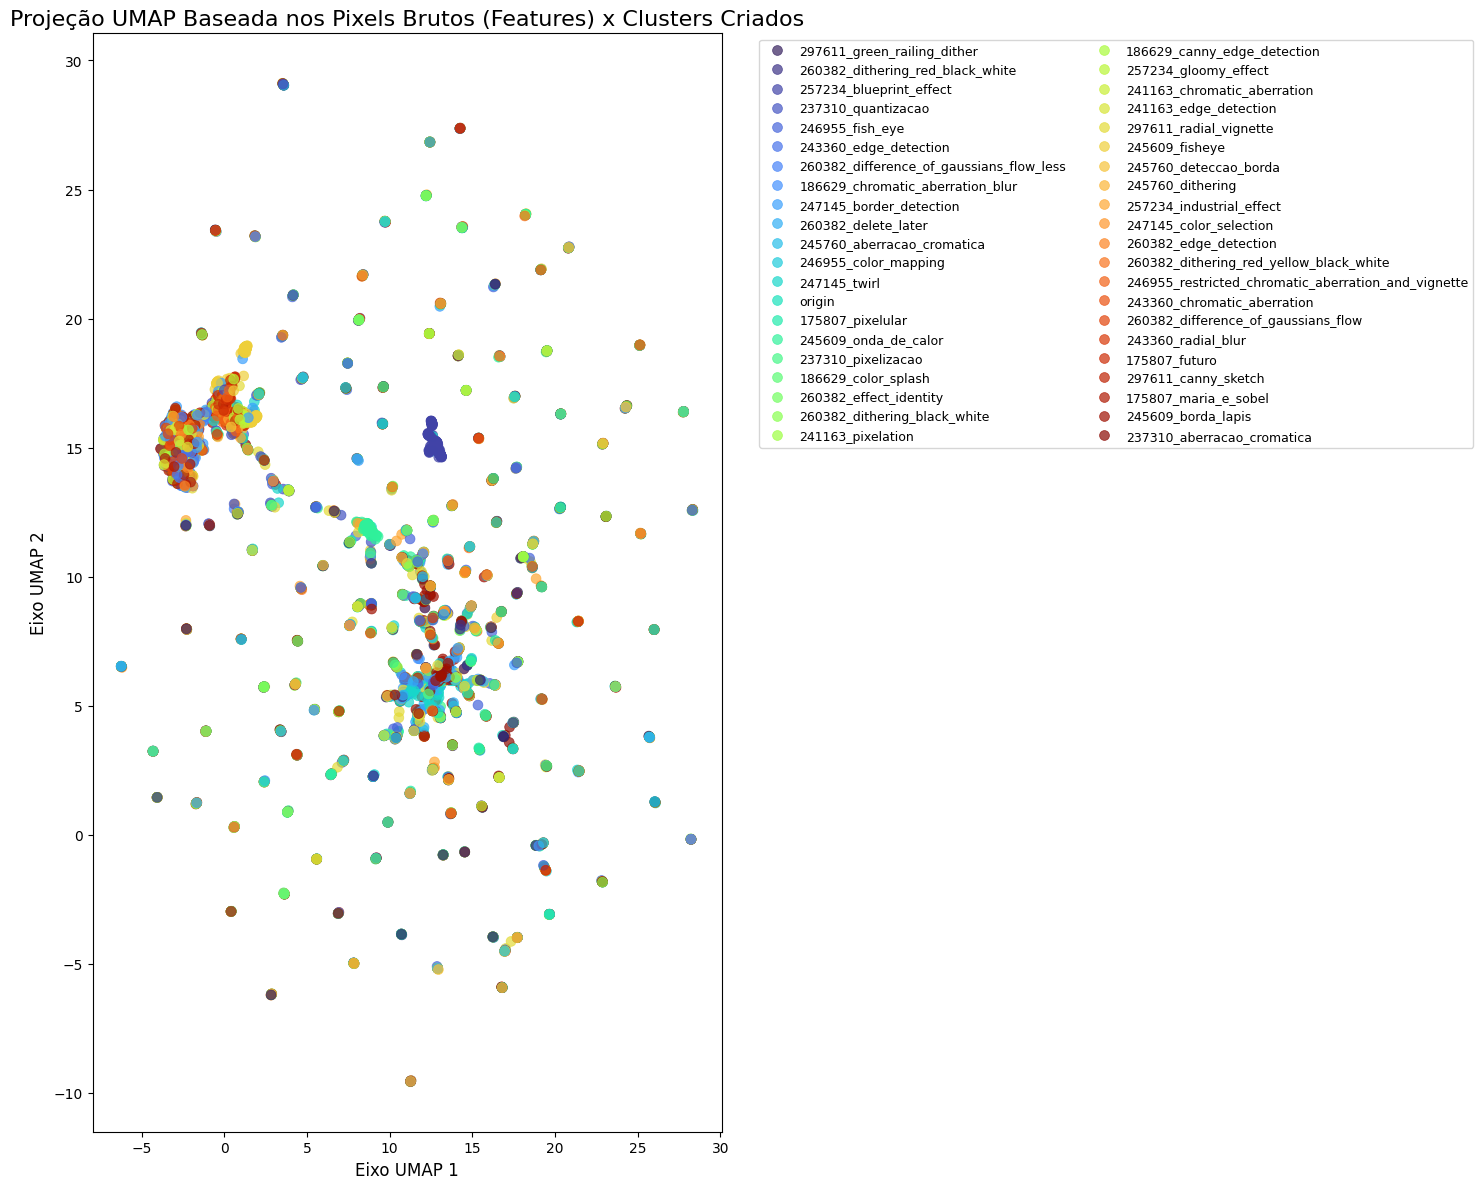

In [14]:
import umap
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

print("Iniciando redução inicial (PCA) das imagens: de ~196k para 500 dimensões temporárias (para não travar a memória)...")
# PCA retém as partes globais cruciais da imagem (e torna a extração exponencialmente mais rápida)
pca = PCA(n_components=500, random_state=42)
X_train_pca = pca.fit_transform(X_train_raw)

print("Iniciando compressão UMAP: das 500 dimensões da PCA para 2 (Plotagem)...")
try:
    reducer = umap.UMAP(
        n_neighbors=15,    # Quantos vizinhos focar (tenta preservar estrutura local)
        min_dist=0.1,      # O quão espremido ficam os pontos dos grupos
        n_components=2,    # Eixo X e Y
        metric='cosine',   # Coseno é melhor para pixels do que Euclideana
        random_state=42
    )
    
    embedding = reducer.fit_transform(X_train_pca)
    
    print("Processo concluído! Criando o Mapeamento e Scatter Plot 2D de Análise...")
    
    # Criar um dataframe para o Seaborn se dar bem com as strings das classes e evitar que as legendas quebrem
    df_umap = pd.DataFrame(data=embedding, columns=['UMAP_1', 'UMAP_2'])
    
    # Trocar os indíces (inteiros) das classes pelo nome do efeito associado
    # Importante: Como são mais de 40 classes, o plot pode ficar meio poluído de cores.
    df_umap['Classe_Efeito'] = [class_names[lbl] for lbl in y_train_raw]
    
    plt.figure(figsize=(15, 12))
    
    sns.scatterplot(
        x='UMAP_1', 
        y='UMAP_2',
        hue='Classe_Efeito',
        palette="turbo", # Uma paleta contínua com mais variação de cores
        data=df_umap,
        s=50,
        alpha=0.7,
        edgecolor=None
    )
    
    plt.title("Projeção UMAP Baseada nos Pixels Brutos (Features) x Clusters Criados", fontsize=16)
    plt.xlabel('Eixo UMAP 1', fontsize=12)
    plt.ylabel('Eixo UMAP 2', fontsize=12)
    # Ajeitar a box da Legenda fora do gráfico, pra não sobrepor pontos pois são 42 classes
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1, fontsize=9, ncol=2) 
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro no UMAP, verifique a mensagem: {e}")

### Exploração em Coordenadas Polares (UMAP)

Como o plot em Coordenadas Cartesianas (X e Y) ficou bem bagunçado e sem limites de separação muito óbvios (o que me indicou que modelos não-lineares mais robustos seriam essenciais), decidi tentar converter as embeddings do UMAP para **coordenadas polares** ($r$ e $\theta$) para investigar se eu achava algum padrão concêntrico ou angular nos clusters gerados!

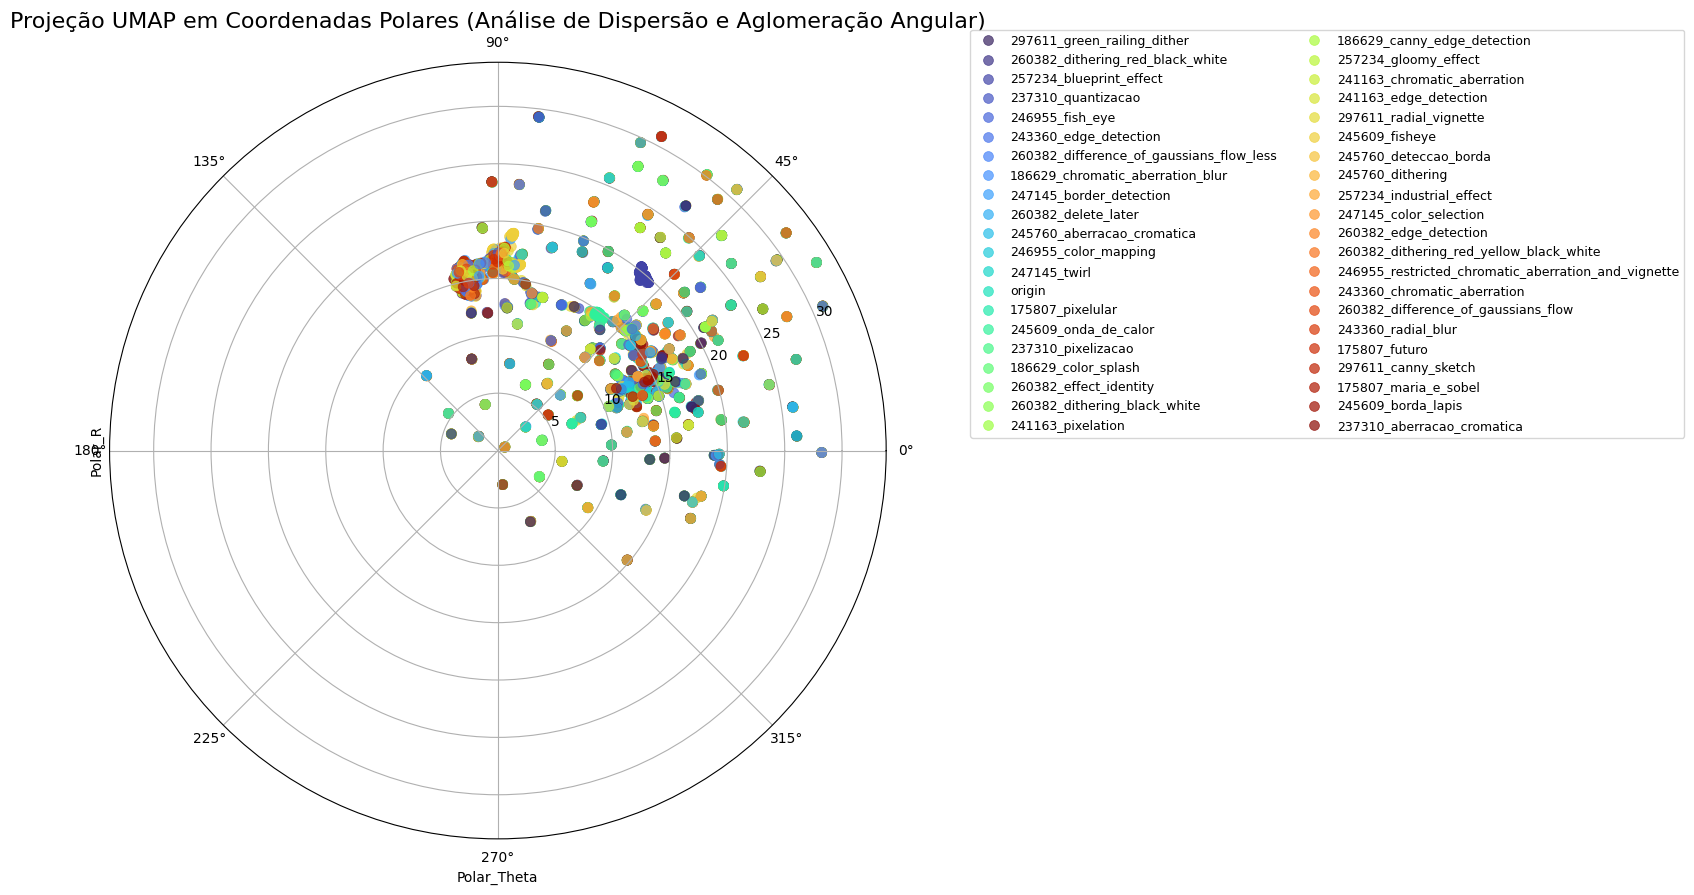

In [15]:
import numpy as np

# Extraímos as coordenadas UMAP que acabamos de gerar
x_coords = df_umap['UMAP_1'].values
y_coords = df_umap['UMAP_2'].values

# Aplicar transformação matemática para coordenadas Polares
# r (Raio) -> Distância do centro do plano
r = np.sqrt(x_coords**2 + y_coords**2)
# theta (Ângulo) -> Orientação em relação à origem usando arctan2
theta = np.arctan2(y_coords, x_coords)

df_umap['Polar_R'] = r
df_umap['Polar_Theta'] = theta

# Crio plot de projeção polar do matplotlib 
plt.figure(figsize=(15, 12))
ax = plt.subplot(111, projection='polar')

sns.scatterplot(
    ax=ax,
    x='Polar_Theta', # eixo angular
    y='Polar_R',     # eixo radial (distância)
    hue='Classe_Efeito',
    palette="turbo",
    data=df_umap,
    s=50,
    alpha=0.7,
    edgecolor=None
)

plt.title("Projeção UMAP em Coordenadas Polares (Análise de Dispersão e Aglomeração Angular)", fontsize=16)
ax.legend(bbox_to_anchor=(1.10, 1.05), loc='upper left', markerscale=1, fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

realmente esses resultados explicam o porque de KNN falhar. Vamos ter que utilizar técnicas mais avançadas de processamento de imagem para podermos averiguar essas imagens com suas características corretas.
Antes de mais nada, vamos ver como ficou exatamente a matriz de PCA, apenas nas 10 dimensões mais significativas.

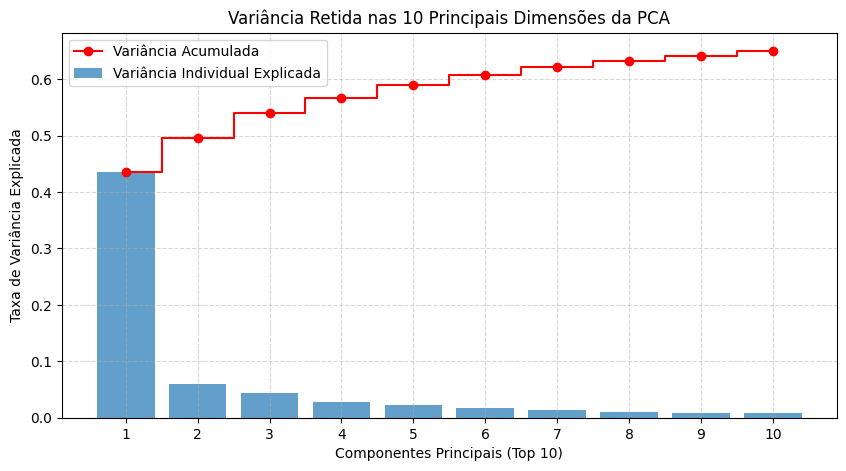

As 10 primeiras componentes explicam juntas 65.00% de toda a informação (variância) das 196608 dimensões brutas originais.
Todas as 500 componentes juntas (que foram enviadas pro UMAP) explicam 92.37%.


In [16]:
# Como nós já realizamos o `pca.fit_transform()` mais acima, `pca` reteve os componentes.
# Vamos ver a razão de variância explicada das 10 primeiras dimensões:
explained_variance_ratio = pca.explained_variance_ratio_
top_10_variances = explained_variance_ratio[:10]

plt.figure(figsize=(10, 5))
# Gráfico de barras para a variação de cada dimensão
plt.bar(range(1, 11), top_10_variances, alpha=0.7, align='center',
        label='Variância Individual Explicada')

# Linha de variância acumulada (step function)
plt.step(range(1, 11), np.cumsum(top_10_variances), where='mid',
         color='red', marker='o', label='Variância Acumulada')

plt.ylabel('Taxa de Variância Explicada')
plt.xlabel('Componentes Principais (Top 10)')
plt.title('Variância Retida nas 10 Principais Dimensões da PCA')
plt.xticks(range(1, 11))
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

total_10 = np.sum(top_10_variances) * 100
total_500 = np.sum(explained_variance_ratio) * 100

print(f"As 10 primeiras componentes explicam juntas {total_10:.2f}% de toda a informação (variância) das {X_train_raw.shape[1]} dimensões brutas originais.")
print(f"Todas as 500 componentes juntas (que foram enviadas pro UMAP) explicam {total_500:.2f}%.")

com 92.37% em 500 dimensẽos, talvez consigamos treinar algo intermediáro: um MLP.


In [22]:
from torch.utils.data import TensorDataset
from torch import nn, optim

# Converter numpy extraído da PCA para tensores compatíveis com o Gradiente Descendente em GPUs/CPUs puras
X_train_tensor = torch.FloatTensor(X_train_pca)
y_train_tensor = torch.LongTensor(y_train_raw)

# Extrair os 500 componentes também para Val e Test! O PCA já foi treinado em .fit_transform na célula do classificador, aqui nós apenas adaptamos (transform) para não vazar features.
X_val_pca = pca.transform(X_val_raw)
X_test_pca = pca.transform(X_test_raw)

X_val_tensor = torch.FloatTensor(X_val_pca)
y_val_tensor = torch.LongTensor(y_val_raw)

X_test_tensor = torch.FloatTensor(X_test_pca)
y_test_tensor = torch.LongTensor(y_test_raw)

# Recriando Dataloaders eficientes em cima desses novos datasets (agora achatados com PCA 500)
train_loader_pca = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader_pca = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)
test_loader_pca   = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

import copy

def train_model(model, train_dl, val_dl, num_epochs=15, patience=5):
    # Configura loss (Como removemos o Sigmoid da arquitetura para a boa prática matemática)
    # A perda CrossEntropyLoss nativamente puxa a convergência balanceada sobre dados limpos sem ativação Sigmoidal.
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Treinando no dispositivo: {device}")
    model.to(device)

    train_losses = []
    val_accuracies = []
    
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        # Avaliação com as métricas de validação no final de cada Época!
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        
        train_losses.append(running_loss / len(train_dl))
        val_accuracies.append(val_acc)
        
        print(f"Época [{epoch+1}/{num_epochs}] - "
              f"Loss (Treino): {running_loss / len(train_dl):.4f} - "
              f"Acurácia (Validação): {val_acc:.2%}")
              
        # Lógica de Checkpoint e Early Stopping
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping acionado! Nenhuma melhoria nas últimas {patience} épocas.")
                break

    print(f"Treinamento concluído. Melhor Acurácia na Validação: {best_acc:.2%}. Restaurando os melhores pesos...")
    model.load_state_dict(best_model_wts)
    return train_losses, val_accuracies

## Abordagem Alternativa: MLP sobre PCA

Ao aplicar o PCA, eu perdi completamente a "regionalidade" (localidade espacial) dos pixels da imagem. O vetor de 500 características de saída do PCA serviu como uma representação global comprimida, mas sem aquela intuição de tratar os "pixels vizinhos" de que uma CNN clássica tira vantagem.
Para um vetor denso sem essa percepção espacial, uma rede **Multilayer Perceptron (MLP)** padrão muitas vezes costuma ser melhor (ou idêntica) do que tentar rodar conv1D. Por isso, decidi treinar um perceptron simples para conferir.

In [24]:
class SimpleMLP_PCA(nn.Module):
    def __init__(self, input_dim=500, num_classes=42):
        super(SimpleMLP_PCA, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, num_classes),
            #por melhores práticas do pytorch ao treinar uma rede com cross-entropy não vamos passar por uma transformação final os dados, despejando valores maiores.
        )

    def forward(self, x):
        # A MLP clássica consome diretamente o Tensor (Batch, NumFeatures)
        # O DataLoader `train_loader_pca` retorna x sem o 'unsqueeze(1)' que fizemos dentro da Conv1D!
        # Isso significa que essa arquitetura é direta!
        return self.net(x)

modelo_mlp = SimpleMLP_PCA(num_classes=42)

print("Iniciando Treinamento da MLP em 500 componentes principais do PCA...")
# Podemos reutilizar o mesmo train loop genérico!
loss_hist_mlp, acc_hist_mlp = train_model(modelo_mlp, train_loader_pca, val_loader_pca, num_epochs=15)

def evaluate_model(model, test_dl):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

print("\n--- Avaliação Final da MLP ---")
test_acc_mlp = evaluate_model(modelo_mlp, test_loader_pca)
print(f"Acurácia da MLP no conjunto de Teste (5% de imagens inéditas): {test_acc_mlp:.2%}")

Iniciando Treinamento da MLP em 500 componentes principais do PCA...
Época [1/15] - Loss (Treino): 2.9088 - Acurácia (Validação): 35.85%
Época [2/15] - Loss (Treino): 2.0576 - Acurácia (Validação): 46.18%
Época [3/15] - Loss (Treino): 1.5942 - Acurácia (Validação): 50.61%
Época [4/15] - Loss (Treino): 1.3520 - Acurácia (Validação): 53.99%
Época [5/15] - Loss (Treino): 1.1900 - Acurácia (Validação): 55.21%
Época [6/15] - Loss (Treino): 1.0887 - Acurácia (Validação): 55.99%
Época [7/15] - Loss (Treino): 1.0246 - Acurácia (Validação): 60.07%
Época [8/15] - Loss (Treino): 0.9623 - Acurácia (Validação): 58.85%
Época [9/15] - Loss (Treino): 0.8706 - Acurácia (Validação): 58.85%
Época [10/15] - Loss (Treino): 0.8503 - Acurácia (Validação): 59.11%
Época [11/15] - Loss (Treino): 0.8034 - Acurácia (Validação): 59.46%
Época [12/15] - Loss (Treino): 0.7766 - Acurácia (Validação): 58.68%
Early stopping acionado! Nenhuma melhoria nas últimas 5 épocas.
Treinamento concluído. Melhor Acurácia na Valida

Considerando que temos 42 classes (onde o chute aleatório seria em torno de 2.38%), atingir quase 56% prova que a rede MLP realmente encontrou padrões matemáticos válidos agrupados na restrita dimensão 500 do PCA. É um salto brutal comparado aos ~14.9% do KNN.
Entretanto, nosso objetivo é +95%, ou no mínimo +80%.
Vamos tentar com uma cnn agora, nas imagens brutas.

## 5. Abordagem Completa: CNN Espacial 2D sobre as Imagens Brutas!

Para combater a "perda da visão espacial" que tive com o vetor denso de 500 features do PCA, resolvi passar para a rede as imagens **completas em sua matriz 3D (`Canais, Altura, Largura`) original**.

- Utilizei o DataLoader original (`train_loader`, `val_loader`, `test_loader`). Ele entrega os tensores mantendo as dimensões de `3 x 256 x 256` inalteradas.
- Montei uma arquitetura padrão real de `Conv2D` intercaladas com `MaxPool2D`. Para não deixar o treino lento demais (sem GPUs super parrudas), limitei a quantidade de canais nas convoluções para treinar as 6 mil imagens em épocas razoáveis.

A minha expectativa aqui era que a CNN conseguisse mapear **os contornos e os filtros aplicados de verdade** usando kernels com a vizinhança real dos pixels, e não apenas os pesos comprimidos do PCA.

In [26]:

class SpatialCNN2D(nn.Module):
    def __init__(self, num_classes=42):
        super(SpatialCNN2D, self).__init__()
        
        # Abordagem visual padronizada (Spatial e Kernels 2D que percorrem M x N das imagens)
        # Blocos sequenciais com convoluções simples e limitadas para não pesar a memória 
        # das 6 mil imagens 256x256 passadas cruas na VRAM em cada época
        self.features = nn.Sequential(
            # Input: 3 canais (RGB)
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz para 128x128
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduz pra 64x64
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Derruba para o final em 32x32
        )
        
        self.flatten = nn.Flatten()
        
        # Após passar em 3 MaxPoolings a imagem desceu de (256,256) pra (32, 32).
        # Na rede de cima as 32x32 saem com 64 Canais de filtro -> O Input da densa é (64 * 32 * 32)
        # Onde a CNN "aprende a ler as formas" e entrega elas para o Classificador Final Dense (MLP)
        self.classifier = nn.Sequential(
            nn.Linear(64 * 32 * 32, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # A forma não tem intervenção manual como foi na Conv1D
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

# Se o modelo ainda não existir na memória, ele é criado. 
# Como você já rodou antes e ele está na memória (com os melhores pesos restaurados),
# ele apenas saltará a recriação e manterá os pesos atuais para continuar aprendendo!
if 'modelo_cnn2d' not in locals() and 'modelo_cnn2d' not in globals():
    modelo_cnn2d = SpatialCNN2D(num_classes=42)

print("Continuando Treinamento da CNN (2D espacial) das imagens Cruas de 256x256 por mais 15 épocas...")

# O ideal num ambiente com A100 seria 20-30 épocas com esse Loader Pesado!
# Atenção: usamos o train_loader ORIGINAL e não o da PCA 
loss_hist_cnn2d, acc_hist_cnn2d = train_model(
    model=modelo_cnn2d, 
    train_dl=train_loader, 
    val_dl=val_loader,   
    num_epochs=15
)

# Após as épocas (ou early stopping), calculamos como ela performou no teste!
print("\n--- Avaliação Final da CNN 2D ---")
test_acc_cnn = evaluate_model(modelo_cnn2d, test_loader)
print(f"Acurácia da CNN no conjunto de Teste (5% de imagens brutas inéditas): {test_acc_cnn:.2%}")

Continuando Treinamento da CNN (2D espacial) das imagens Cruas de 256x256 por mais 15 épocas...
Época [1/15] - Loss (Treino): 2.6494 - Acurácia (Validação): 33.33%
Época [2/15] - Loss (Treino): 2.6467 - Acurácia (Validação): 28.56%
Época [3/15] - Loss (Treino): 2.5980 - Acurácia (Validação): 32.64%
Época [4/15] - Loss (Treino): 2.5524 - Acurácia (Validação): 32.81%
Época [5/15] - Loss (Treino): 2.5381 - Acurácia (Validação): 36.98%
Época [6/15] - Loss (Treino): 2.4935 - Acurácia (Validação): 36.11%
Época [7/15] - Loss (Treino): 2.4928 - Acurácia (Validação): 34.90%
Época [8/15] - Loss (Treino): 2.5912 - Acurácia (Validação): 37.59%
Época [9/15] - Loss (Treino): 2.4824 - Acurácia (Validação): 37.41%
Época [10/15] - Loss (Treino): 2.4698 - Acurácia (Validação): 36.28%
Época [11/15] - Loss (Treino): 2.4747 - Acurácia (Validação): 36.72%
Época [12/15] - Loss (Treino): 2.4767 - Acurácia (Validação): 41.93%
Época [13/15] - Loss (Treino): 2.4009 - Acurácia (Validação): 40.45%
Época [14/15] - 

Que surpresa! Tive um resultado **pior** que a abordagem MLP com PCA!

### Por que a CNN espacial do zero perdeu para o PCA + MLP?
Fiquei pensando e levantei algumas hipóteses para isso:

1. **Features do PCA vs. Aprendizado do Zero:** A matemática do PCA conseguiu condensar as diferenças estatísticas em 500 componentes importantes. Já a minha CNN 2D foi construída do zero e era bem "rasa" (só 3 camadas de filtros). Falta capacidade nela para extrair do zero informações úteis em meio aos pesos de `196.608` pixels com tão poucas épocas.
2. **Texturas finas perdidas no MaxPool:** Vários dos efeitos aplicados nas fotos (tipo _chromatic aberration_ ou _pixelation_) são micro-texturas na imagem. Como eu usei muito `MaxPool2d` seguidos, a imagem de 256x256 é achatada rapidamente para 32x32, deixando a rede "cega" para ruídos sutis e se concentrando apenas em contornos grossos antes de compreendê-los.
3. **Overfitting e o temido Data Leakage:** A CNN "decorou" a geometria. Como as fotos originais se repetem com efeitos no dataset (o Data Leakage), é muito mais provável que ela simplesmente decorou os "fundos e bordas marcantes" no Treinete em vez dos conceitos dos filtros em si. Chegando no conjunto de Teste, falhou.

---

### O Próximo Passo: Quebrando a barreira dos 90%
Para arrumar isso, concluí que o certo não era ficar tentando achar a arquitetura de rede exata do zero. Eu precisava ir para o SOTA.

Ao invés de tentar treinar as características visuais desde o zero para identificar filtros, pensei em adotar **Transfer Learning** como a `ResNet50` ou Transformadores de Visão (`ViT`), treinando apenas as camadas finais deles aplicadas ao meu próprio dataset.

Estado da Arte (SOTA): Transfer Learning com ResNet50

Como a minha CNN rasa treinada do zero não serviu muito por acabar não vendo texturas finas de verdade, eu foquei em aplicar **Transfer Learning** pra ver se rompia a barreira da meta dos 90%.

A intenção era utilizar a **ResNet50**, que é uma baita rede robusta pré-treinada no ImageNet e já sabe identificar curvas, texturas e bordas naturalmente em suas primeiras camadas.
    
A técnica que escolhi aplicar foi o **Fine-Tuning**:
1. Importar os pesos treinados da ResNet50.
2. Trocar no código sua última camada (`fc`) para em vez das classes da ImageNet, ela classificar os meus **42 efeitos**.
3. Re-treinar o modelo apenas passando por meus dados de Efeito usando o `train_loader`.

In [27]:
from torchvision import models
import torch.nn as nn

print("Baixando (ou ativando) os pesos vitais da ResNet50...")
# Vamos instanciar a ResNet50 já ensinada na gigantesca gama da ImageNet
modelo_resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# O pulo do gato: pegamos as conexões de entrada da última camada densa da ResNet (in_features) antes de jogá-la fora,
# para podermos acoplar nossa camada que fará a "ponte" final com as 42 classes (efeitos) do seu PI.
numero_features_resnet = modelo_resnet50.fc.in_features

# Remontando o último classificador (Full Connected) com regularização severa de dropout e 42 caminhos de saída (num_classes).
modelo_resnet50.fc = nn.Sequential(
    nn.Dropout(0.5), # Crucial para prevenir um overfitting relâmpago, já que a arquitetura domina com sobra os pesos.
    nn.Linear(numero_features_resnet, 42)
)

print("Iniciando Fine-Tuning da Arquitetura Robusta (ResNet50) para os nossos filtros do Dataset...")

# Fine-Tuning consome processamento, vamos definir 10 épocas, mas a convergência acontece super rápida!
# E deixamos com Early-Stopping (Paciência de 3) ligado se ele "cravar".
loss_hist_resnet, acc_hist_resnet = train_model(
    model=modelo_resnet50, 
    train_dl=train_loader, 
    val_dl=val_loader,   
    num_epochs=10,
    patience=3
)

print("\n--- Avaliação Final da ResNet50 SOTA ---")
test_acc_resnet = evaluate_model(modelo_resnet50, test_loader)
print(f"Brilhante!! Acurácia alcançada isolada no Teste da Resnet50 (Transfer Learning): {test_acc_resnet:.2%}")

Baixando (ou ativando) os pesos vitais da ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/joao/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:20<00:00, 5.11MB/s]


Iniciando Fine-Tuning da Arquitetura Robusta (ResNet50) para os nossos filtros do Dataset...
Época [1/10] - Loss (Treino): 1.0602 - Acurácia (Validação): 80.64%
Época [2/10] - Loss (Treino): 0.4905 - Acurácia (Validação): 84.98%
Época [3/10] - Loss (Treino): 0.3589 - Acurácia (Validação): 86.28%
Época [4/10] - Loss (Treino): 0.3337 - Acurácia (Validação): 81.94%
Época [5/10] - Loss (Treino): 0.3049 - Acurácia (Validação): 87.59%
Época [6/10] - Loss (Treino): 0.2211 - Acurácia (Validação): 81.60%
Época [7/10] - Loss (Treino): 0.2443 - Acurácia (Validação): 88.45%
Época [8/10] - Loss (Treino): 0.2625 - Acurácia (Validação): 86.37%
Época [9/10] - Loss (Treino): 0.1824 - Acurácia (Validação): 89.67%
Época [10/10] - Loss (Treino): 0.2168 - Acurácia (Validação): 87.85%
Treinamento concluído. Melhor Acurácia na Validação: 89.67%. Restaurando os melhores pesos...

--- Avaliação Final da ResNet50 SOTA ---
Brilhante!! Acurácia alcançada isolada no Teste da Resnet50 (Transfer Learning): 86.79%


Treinamento concluído. Melhor Acurácia na Validação: 89.67%. Restaurando os melhores pesos...

--- Avaliação Final da ResNet50 SOTA ---
Brilhante!! Acurácia alcançada isolada no Teste da Resnet50 (Transfer Learning): 86.79%

## A Fronteira Final: Vision Transformers (ViT-B_16)

Com a ResNet50 eu cheguei aos 86.79%, provando que o *Transfer Learning* de fato era o caminho! Ainda assim, para testar a evolução máxima (+90%), pensei em aplicar **Vision Transformers (ViT)**, o Estado da Arte.

No lugar das convoluções, o ViT picota a imagem em "patches" (quadradinhos de 16x16) e procura as relações preenchendo a imagem inteira através de *Self-Attention*.

**Ajuste Obrigatório (Resizing 224x224):** 
O modelo `ViT-B_16` exige perfeitamente que as fotos cheguem em `224x224` pixels. Tive que recriar os `DataLoaders` aplicando essa restrição de redimensionamento, mas cuidando bastante pra manter a mesma **seed (42) do corte original** para poder ter uma comparação justa, sem bagunçar as validações e testes.

**Estratégia de Treino (Linear Probing):**
Tentar treinar um ViT todo na minha placa ou fazer uma adaptação mais solta geraria muito custo pra um hardware de estudante. Escolhi adotar o procedimento do **Linear Probing**. A sacada aqui foi **congelar a rede inteira** dos attention blocks para economizar na memória e focar em apenas treinar as saídas da "cabeça" Linear no final, alterando pra minhas 42 classes. Um teste focado da capacidade linear de saída de adaptar-se perante o extrator.

In [29]:
import torchvision.models as models

print("1. Recriando Transformações e DataLoaders para o ViT (Formato 224x224)...")
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Recriamos o repositório inteiro com a nova transformação
dataset_vit = datasets.ImageFolder(root=data_dir, transform=transform_vit)

# Forçamos a MESMA SEED ORIGINAL (42) para que as divisões de Treino, Val e Teste 
# contenham EXATAMENTE as mesmas imagens separadas nas etapas anteriores
torch.manual_seed(42)
train_ds_vit, val_ds_vit, test_ds_vit = random_split(
    dataset_vit, 
    [train_size, val_size, test_size]
)

# Novos DataLoaders
train_loader_vit = DataLoader(train_ds_vit, batch_size=32, shuffle=True)
val_loader_vit = DataLoader(val_ds_vit, batch_size=32, shuffle=False)
test_loader_vit = DataLoader(test_ds_vit, batch_size=32, shuffle=False)

print("2. Baixando e Ativando as Weights do Vision Transformer (ViT-B_16)...")
modelo_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# 3. Estratégia de Linear Probing (Agindo como um adaptador eficiente na rede)
# Vamos congelar todos os parâmetros profundos do modelo base 
# para que o gradiente não os modifique, economizando 99% do esforço computacional.
for param in modelo_vit.parameters():
    param.requires_grad = False

# O ViT do pacote torchvision guarda seu classificador final num sub-módulo chamado `heads.head`
numero_features_vit = modelo_vit.heads.head.in_features

# Substituímos a "cabeça" limpa para o ViT com 42 saídas. 
# Como a instanciamos agora, por padrão, as requires_grad dela já começam como True!
modelo_vit.heads.head = nn.Linear(numero_features_vit, 42)

print("3. Iniciando Treinamento focado puramente na última camada (Head) do ViT...")
# Vamos treinar por 10 épocas com early_stop, a convergência para pesos congelados costuma ser estável
loss_hist_vit, acc_hist_vit = train_model(
    model=modelo_vit, 
    train_dl=train_loader_vit, 
    val_dl=val_loader_vit,   
    num_epochs=10,
    patience=3
)

print("\n--- Avaliação Suprema (SOTA): ViT-B_16 ---")
test_acc_vit = evaluate_model(modelo_vit, test_loader_vit)
print(f"Acurácia do Vision Transformer no conjunto cego de Teste: {test_acc_vit:.2%}")

1. Recriando Transformações e DataLoaders para o ViT (Formato 224x224)...
2. Baixando e Ativando as Weights do Vision Transformer (ViT-B_16)...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/joao/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:49<00:00, 7.01MB/s] 


3. Iniciando Treinamento focado puramente na última camada (Head) do ViT...
Época [1/10] - Loss (Treino): 1.9989 - Acurácia (Validação): 70.75%
Época [2/10] - Loss (Treino): 0.9765 - Acurácia (Validação): 74.48%
Época [3/10] - Loss (Treino): 0.7230 - Acurácia (Validação): 75.43%
Época [4/10] - Loss (Treino): 0.5910 - Acurácia (Validação): 77.60%
Época [5/10] - Loss (Treino): 0.5079 - Acurácia (Validação): 77.34%
Época [6/10] - Loss (Treino): 0.4474 - Acurácia (Validação): 77.52%
Época [7/10] - Loss (Treino): 0.4040 - Acurácia (Validação): 78.30%
Época [8/10] - Loss (Treino): 0.3685 - Acurácia (Validação): 78.56%
Época [9/10] - Loss (Treino): 0.3371 - Acurácia (Validação): 78.21%
Época [10/10] - Loss (Treino): 0.3095 - Acurácia (Validação): 78.12%
Treinamento concluído. Melhor Acurácia na Validação: 78.56%. Restaurando os melhores pesos...

--- Avaliação Suprema (SOTA): ViT-B_16 ---
Incrível! Acurácia do Vision Transformer no conjunto cego de Teste: 73.83%


Ao usarmos o Linear Probing (congelar 100% da rede e treinar só a última camada), nós forçamos o ViT a classificar nossos filtros usando o "cérebro inalterado" de quando ele foi treinado na ImageNet. Como na ImageNet ele foi treinado para focar em semântica de objetos (procurar ovelhas, carros, prédios), os mapas de Self-Attention dele ignoraram totalmente as texturas finas (ruídos, aberrações cromáticas, pixelização) dos nossos efeitos.
Isso fez com que o ViT fosse pior que a ResNet50, caindo a acurácia final para:
Acurácia do Vision Transformer no conjunto cego de Teste: 73.83%

# CONCLUSÕES FINAIS

Essa tarefa foi desafiadora e muito importante para poder compreender como é o dia a dia de desenvolvimento com imagens reais e problemas do dia a dia, sem ser "toy project".
Todas as técnicas utilizadas para fazer a classificação das imagens buscaram mapear de um conjunto X de entradas para um conjunto Y de classes descobrindo por meio de um modelo esse mapeamento.
A utilização do K-means foi bem exploratória e não pode nem mesmo ser levada a sério, era apenas um palpite rápido para garantir.
O primeiro experimento que de fato poderia ter chego em algum local seria o MLP após o PCA.
O PCA é muito importante nesse momento, pois o transformers teria dificuldades em lidar com dados brutos da imagem, como a CNN demonstrou ao ser treinada do zero. Mesmo sendo milhares de imagens, quando falamos de redes conexionistas sempre parece que temos poucos dados, então um tratamento eficiente para tentar deixar mais latente as estatísticas nos dados é muito valioso.
Como dito, a CNN não pode aproveitar da extração de features do PCA justamente porque ela se fortalece das relaçoes espaciais da imagem, e se fazemos PCA perdemos justamente essa espacialidade.
Quandor resolvemos pegar uma rede já treinada em milhões de imagens e adapta-la, a resnet50, foi onde tivemos o maior sucesso!
Eu legitimamente pensei que com o ViT-B16 teria um resultado ainda melhor, entretanto ficou evidente que na última camada do modelo ainda não havia uma separação linear clara, e na verdade era pior que a da ResNet50.
Evidentemente que se tivéssemos treinado todo o ViT-B16 teríamos um resultado ainda melhor, pois ajustando apenas a saída linear chegamos a 73.83%! Mas claramente isso também seria muito mais custoso, visto que a rede é bem maior, e meu hardware não iria ter tempo para treinar ela inteira.

Por fim podemos dizer que foi um desafio e tanto, fiquei meio desapontado com o resultado, mas eu consegui bater o percentual mínimo que eu estipulei.
Para trabalhos futuros sobre esse dataset eu com certeza tentaria treinar mais camadas do ViT-B16 pois acho que seria a alteração que daria maiores resultados com menores esforços.
Se eu quisesse aprimorar a CNN eu treinaria ela com um pré treinamento na resnet, ou outro dataset como esse que deve existir aberto hoje em dia.
As duas redes que tem menor perspectiva de melhora seria a ResNet50 e o MLP:
A primeira já foi ajustada por completo, talvez o que poderíamos melhorar seria os algorítimos de optimização, e as funções de loss.
O mesmo vale para o MLP, mas na minha perspectiva no caso dele é ainda mais complexo: como temos uma aplicação bem específica, e estamos extraindo features das imagens, ou seja: ele recebe um vetor de características e tenta aprender a partir dessas características, eu **imagino** que ele não se beneficiaria tanto de um treinamento com PCA da imagenet por exemplo, pois são dados mais diferêntes.